In [1]:
import torch
print(torch.cuda.is_available())   # → True
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
from datetime import datetime
import mujoco

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from gymnasium.envs.mujoco.humanoid_v5 import HumanoidEnv
from gymnasium.envs.registration import register
from IPython.display import HTML
from IPython.display import Video
from IPython.display import display, clear_output
from PIL import Image as PILImage

from stable_baselines3 import SAC, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback

import glob

import os
#os.environ["MUJOCO_GL"] = "glfw"

pd.set_option('display.max_columns', None)

<p>
  <img src="Humanoid.png" alt="Humanoid" width="800">
</p>

In [2]:
def Record_Video(model, path_videos):
    os.makedirs(path_videos, exist_ok=True)
    
    record_env = gym.make("Humanoid-v5", render_mode="rgb_array")
    record_env = RecordVideo(record_env, path_videos , episode_trigger=lambda x: True)
    print("Recorded in: ", path_videos)

    obs, _ = record_env.reset()

    max_videos = 3
    k = 0
    for _ in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = record_env.step(action)

        if done or truncated:
            k += 1
            obs, _ = record_env.reset()
            if k >= max_videos:
                break

    record_env.close()
    
def extraer_timesteps(nombre: str) -> int | None:
    """Extrae el número entre 'final_' y el siguiente '_'."""
    match = re.search(r'final_(\d+)(?:_|$)', nombre)
    return int(match.group(1)) if match else None

Funcion step de mi enviroment:

    def step(self, action):
        xy_position_before = mass_center(self.model, self.data)
        self.do_simulation(action, self.frame_skip)
        xy_position_after = mass_center(self.model, self.data)

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self._get_obs()
        reward, reward_info = self._get_rew(x_velocity, action)
        terminated = (not self.is_healthy) and self._terminate_when_unhealthy
        info = {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "tendon_length": self.data.ten_length,
            "tendon_velocity": self.data.ten_velocity,
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()
        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        return observation, reward, terminated, False, info

    def _get_rew(self, x_velocity: float, action):
        forward_reward = self._forward_reward_weight * x_velocity
        healthy_reward = self.healthy_reward
        rewards = forward_reward + healthy_reward

        ctrl_cost = self.control_cost(action)
        contact_cost = self.contact_cost
        costs = ctrl_cost + contact_cost

        reward = rewards - costs

        reward_info = {
            "reward_survive": healthy_reward,
            "reward_forward": forward_reward,
            "reward_ctrl": -ctrl_cost,
            "reward_contact": -contact_cost,
        }

        return reward, reward_info

In [4]:
# 1. Crear entorno y acceder a la clase base (sin wrappers)
env = gym.make("Humanoid-v5", render_mode="rgb_array", ctrl_cost_weight= 0.3, forward_reward_weight=3)
base = env.unwrapped

print("🔹 CLASE:", type(base).__name__)
print("🔹 OBSERVATION SPACE:", base.observation_space)
print("🔹 ACTION SPACE:", base.action_space)

# 2. Listar atributos internos (evitamos métodos y privados)
print("\n📦 ATRIBUTOS INTERNOS:")
for key in sorted(vars(base)):
    if not key.startswith('_'):
        val = getattr(base, key)
        # Truncar valores largos para que la salida sea legible
        if hasattr(val, '__len__') and len(val) > 20:
            val = f"<{type(val).__name__} shape={getattr(val, 'shape', len(val))}>"
        elif isinstance(val, float):
            val = f"{val:.4f}"
        print(f"  {key}: {val}")

# 3. Búsqueda enfocada en parámetros de reward/costo
print("\n🎯 PARÁMETROS RELACIONADOS CON REWARDS/COSTOS:")
keywords = ['weight', 'reward', 'cost', 'bonus', 'penalty', 'scale', 'target']
found = False
for key in vars(base):
    print("key: ", key)
    if any(k in key.lower() for k in keywords):
        found = True
        #print(f"  {key}: {getattr(base, key)}")
    print(f"  {key}: {getattr(base, key)}")
if not found:
    print("  ⚠️ No se encontraron atributos directos. En v5 pueden estar en self._reward_spec o calcularse en step().")

🔹 CLASE: HumanoidEnv
🔹 OBSERVATION SPACE: Box(-inf, inf, (348,), float64)
🔹 ACTION SPACE: Box(-0.4, 0.4, (17,), float32)

📦 ATRIBUTOS INTERNOS:
  action_space: Box(-0.4, 0.4, (17,), float32)
  camera_id: None
  camera_name: None
  data: <mujoco._structs.MjData object at 0x000002AA272763B0>
  frame_skip: 5
  fullpath: <str shape=95>
  height: 480
  init_qpos: <ndarray shape=(24,)>
  init_qvel: <ndarray shape=(23,)>
  metadata: {'render_modes': ['human', 'rgb_array', 'depth_array', 'rgbd_tuple'], 'render_fps': 67}
  model: <mujoco._structs.MjModel object at 0x000002AA25BECB30>
  mujoco_renderer: <gymnasium.envs.mujoco.mujoco_rendering.MujocoRenderer object at 0x000002AA277F17F0>
  observation_space: Box(-inf, inf, (348,), float64)
  observation_structure: {'skipped_qpos': 2, 'qpos': 22, 'qvel': 23, 'cinert': 130, 'cvel': 78, 'qfrc_actuator': 17, 'cfrc_ext': 78, 'ten_length': 0, 'ten_velocity': 0}
  render_mode: rgb_array
  spec: EnvSpec(id='Humanoid-v5', entry_point='gymnasium.envs.mujoc

In [ ]:
import inspect

print(inspect.getsource(base.step))

In [3]:
# para funcionamiento en .py


import custom_humanoid

env = gym.make("CustomHumanoid-v0")
obs, info = env.reset()

init
left knee:  17  right knee:  13


In [ ]:
# policy = elegir las recompensas
# "basic" sin ninguna modificacion de politicas
# velocity => reward = ** * velocity^2
# knees => custom rewards for knees to move
policy = "knees"#"velocity"
lines = 8

if policy == "velocity":
    env = make_vec_env(
                        "Humanoid-v5",
                        n_envs=lines,
                        env_kwargs={"forward_reward_weight": 3.0},  
                        seed=42
)
elif policy == "knees":
    print("Entenamiento Custom version kness")
    env = make_vec_env("CustomHumanoid-v0", n_envs=lines)        
else:
    print("Entenamiento Basico")
    env = make_vec_env("Humanoid-v5", n_envs=lines)

# Configuiraciones: load determina si se carga o no, checkpoint que tipo de carga, y train_* son para los modelos
load = False             # para reanudar entrenamiento             
checkpoint = False       # para reanuder entrenamiento desde checkpoint
train_SAC = True        # para entrenar con SAC
train_TD3 = False       # para entrenar con TD3

time_steps = 30_000_000
eval_parts = 6
part = time_steps / eval_parts

checkpoint_dir = "./checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)

sac_dir = "./sac_models/"
os.makedirs(sac_dir, exist_ok=True)

td3_dir = "./td3_models/"
os.makedirs(td3_dir, exist_ok=True)

fecha = datetime.now().strftime("%Y%m%d")

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=checkpoint_dir,
    name_prefix="sac_ckp" if train_SAC else "td3_ckp"
)
""" los primeros los hice con:
           model = SAC(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99
        ) 

"""
gamma = 0.90
tau = 0.005

sufijo = f"_{fecha}_{policy}_{lines}_g{int(gamma*100)}t{int(tau*1000)}"

model = None

try:
    if train_SAC and not load:
        print("🚀 Iniciando entrenamiento SAC...")
        model = SAC(                    
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=tau, gamma=gamma
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            print("guardar checkpoint")
            model.save(checkpoint_dir + "sac_ckp_" + str( i * part) + sufijo)
            print("videos de ")
            Record_Video(model, (checkpoint_dir + "/videos_sac_" + str( i * part) + sufijo))      
                  
        print("Model_save")
        model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
        print("Model_saved")

    elif train_TD3 and not load:
        print("🚀 Iniciando entrenamiento TD3...")
        n_actions = env.action_space.shape[0]
        action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
        model = TD3(
            "MlpPolicy", env, verbose=0,
            learning_rate=3e-4, buffer_size=1_000_000,
            batch_size=256, tau=0.005, gamma=0.99,
            action_noise=action_noise, policy_delay=2,
            target_policy_noise=0.2, target_noise_clip=0.5
        )
        
        for i in range(eval_parts):
            print("i: ", i)
            model.learn(total_timesteps=part, progress_bar=True,)
                        #callback=checkpoint_callback)
            model.save(checkpoint_dir + "td3_ckp_" + str( i * part) + sufijo)
            
            Record_Video(model, (checkpoint_dir + "/videos_td3_" + str( i * part) + sufijo))            
            
        model.save(td3_dir + "td3_humanoid_final_" + str(time_steps) + sufijo)

    else:
        print("📂 Entrando en modo reanudacion de entrenamiento")
        
        if train_SAC:
            if (checkpoint == True):
                # -----------------------probar
                print("Recuperando checkpoint")
                # Entra al modo recuperacion , pero desde el checkpoint, esta parte esta para recuperar algun entrenamiento que no este completo
                
                # comprueba y adquiere los archivos de checkpoint
                ckpt_files = glob.glob("./checkpoints/sac_ckp_*_steps.zip")
                if not ckpt_files:
                    raise FileNotFoundError("No se encontraron checkpoints en ./checkpoints/")
                
                # elige el de mayor numero de steps
                latest_ckpt = max(ckpt_files, key=lambda f: int(re.search(r'(\d+)_steps\.zip$', f).group(1)))
                print("Debug latest chkpoint: ", latest_ckpt)
            
                model = SAC.load(latest_ckpt, env=env)
                
                print("✅ Reanudando entrenamiento desde checkpoint...")
                
                model.learn(
                    total_timesteps=time_steps, 
                    progress_bar=True, 
                    callback=checkpoint_callback,
                    reset_num_timesteps=False 
                )
                
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
            else:
                # -----------------------probar
                print("Cargando modelo")
                                
                model = SAC.load(sac_dir + "sac_humanoid_final_20000000_20260516_knees_8_g95t5")
                resume_time_steps = extraer_timesteps("sac_humanoid_final_20000000_20260516_knees_8_g95t5")
                part = (time_steps - resume_time_steps) / eval_parts
                model.set_env(env)
                
                print("✅ Reanudando entrenamiento desde modelo entrenado...")
                
                
                
                for i in range(eval_parts):
                    print("i: ", i)
                    model.learn(total_timesteps=part, 
                                progress_bar=True,
                                reset_num_timesteps=False,
                                )

                    model.save(checkpoint_dir + "sac_ckp_" + str( i * part + resume_time_steps) + sufijo)
                    
                    Record_Video(model, (checkpoint_dir + "/videos_sac_" + str( i * part + resume_time_steps) + sufijo))            
                    
                model.save(sac_dir + "sac_humanoid_final_" + str(time_steps) + sufijo)
        else:
            # -----------------------probar
            print("📂 Cargando modelo ...")
            
            
            #model = TD3.load("td3_humanoid_final")


except KeyboardInterrupt:
    print("\n⏹️ Entrenamiento interrumpido manualmente.")
    model.save(("sac_humanoid_last"  + f"_{fecha}") if train_SAC else ("td3_humanoid_last"  + f"_{fecha}"))
    print("💾 Estado guardado. Ejecuta de nuevo con `load = True` para continuar.")

finally:
    env.close()
    print("🏁 Entorno cerrado.")

# Evaluacion

In [4]:
def evaluate_humanoid(env, model, n_episodes=10):
    results = []
    for i in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_len, ep_reward = 0, 0
        log = []
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            # 🎯 Métricas
            ep_len += 1
            ep_reward += reward
            
            data = env.unwrapped.data

            results.append({
                "Episode": i,
                "Ep_len" : ep_len,
                "Ep_reward" : ep_reward,
                "Action" : action,
                "Info": info,
                "Reward" : reward,
                "Qpos" : data.qpos,
                "Qvel" : data.qvel,
                "Obs" : obs,
                "End" : done
            })
    
    # 📈 Resumen estadístico
    return results

In [5]:
def df_expanded (df, col):
    df_expanded = df[col].apply(pd.Series).copy()
    
    if col == "Info":
        df_result = pd.DataFrame(df_expanded.values , columns=("Info_" + df_expanded.columns))
    elif col == "Qpos":
        qpos_names =['root_x', 'root_y', 'root_z', 'root_qw', 'root_qx', 'root_qy', 'root_qz', 'abdomen_z', 'abdomen_y', 'abdomen_x',
                        'right_hip_x', 'right_hip_z', 'right_hip_y', 'right_knee', 'left_hip_x', 'left_hip_z', 'left_hip_y',
                        'left_knee', 'right_shoulder1', 'right_shoulder2', 'right_elbow', 'left_shoulder1', 'left_shoulder2', 'left_elbow']
        qpos_names = [col + "_" + x for x in qpos_names]
        df_result = pd.DataFrame(df_expanded.values , columns=(qpos_names))
    elif col == "Qvel" :
        qvel_names =['root_vx', 'root_vy', 'root_vz', 'root_wx', 'root_wy', 'root_wz', 'abdomen_z_vel', 'abdomen_y_vel', 'abdomen_x_vel',
                        'right_hip_x_vel', 'right_hip_z_vel', 'right_hip_y_vel', 'right_knee_vel', 'left_hip_x_vel', 'left_hip_z_vel',
                        'left_hip_y_vel', 'left_knee_vel', 'right_shoulder1_vel', 'right_shoulder2_vel', 'right_elbow_vel', 'left_shoulder1_vel',
                        'left_shoulder2_vel', 'left_elbow_vel']
        qvel_names = [col + "_" + x for x in qvel_names]
        df_result = pd.DataFrame(df_expanded.values , columns=(qvel_names))
    elif col == "Action" :
        actions =['abdomen_y', 'abdomen_z', 'abdomen_x', 'right_hip_x', 'right_hip_z', 'right_hip_y', 'right_knee', 'left_hip_x', 'left_hip_z',
                    'left_hip_y', 'left_knee', 'right_shoulder1', 'right_shoulder2', 'right_elbow', 'left_shoulder1', 'left_shoulder2',
                    'left_elbow']
        actions = [col + "_" + x for x in actions]
        df_result = pd.DataFrame(df_expanded.values , columns=(actions))
    else:
        df_expanded.columns = [f"{col}_{i+1}" for i in range(df_expanded.shape[1])]
        df_result = pd.DataFrame(df_expanded)
    
    return df_result

In [13]:
def ArreglaryGuardar_df (df, nombre):
    path = "./metricas/"
    
    # Arreglos para los df, que todos tengan su columna
    df_info = df_expanded (df, "Info")
    df_qpos = df_expanded (df, "Qpos")
    df_qvel = df_expanded (df, "Qvel")
    df_action = df_expanded (df, "Action")

    # juntar las columnas extraidas en un df
    df_final = pd.concat([df, df_info], axis=1)
    df_final = pd.concat([df_final, df_qpos] , axis=1)
    df_final = pd.concat([df_final, df_qvel] , axis=1)
    df_final = pd.concat([df_final, df_action], axis=1)

    # hay alguna columna de los resultados que aun necesita ser expandida
    df_tendon_length = df_expanded (df_final, "Info_tendon_length")
    df_tendon_vel = df_expanded (df_final, "Info_tendon_velocity")

    df_final = pd.concat([df_final, df_tendon_length] , axis=1)
    df_final = pd.concat([df_final, df_tendon_vel] , axis=1)

    # guardo las OBS por si llegan a ser necesarias
    df_obs = df_expanded (df, "Obs")

    df_final.drop(columns=["Info", "Qpos", "Qvel", "Action", "Obs", "Info_tendon_length", "Info_tendon_velocity"] , inplace= True)  
    
    df.to_parquet( path + nombre + ".parquet", engine="pyarrow", compression="zstd") 

## Evaluate analisis

In [7]:
analisis = False

base_sac = './sac_models'
archivos_sac = os.listdir(base_sac)
print(archivos_sac)

model = SAC.load(base_sac + '/' + archivos_sac[0])

['sac_humanoid_final_1000000_20260430.zip', 'sac_humanoid_final_1000000_20260515_velocity_2_g0_95t0_005.zip', 'sac_humanoid_final_20000000_20260501.zip', 'sac_humanoid_final_20000000_20260505_velocity.zip', 'sac_humanoid_final_20000000_20260511_basic.zip', 'sac_humanoid_final_20000000_20260512_velocity.zip', 'sac_humanoid_final_20000000_20260516_knees_8_g95t5.zip', 'sac_humanoid_final_2000000_20260505_velocity.zip', 'sac_humanoid_final_30000000_20260520_knees_8_g95t5.zip', 'sac_humanoid_final_30000000_20260521_knees_8_g95t5.zip', 'sac_humanoid_final_30000000_20260525_knees_8_g90t5.zip', 'sac_humanoid_final_40000000_20260518_knees_8_g95t5.zip']


In [8]:
env = gym.make("Humanoid-v5")
env.reset()

action, _ = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

model_env = env.unwrapped.model

if analisis == True:
    joint_names = [model_env.joint(i).name for i in range(model_env.njnt)]
    print("joint len: ", len(joint_names), "joint array: ", joint_names)

    body_names = [model_env.body(i).name for i in range(model_env.nbody)]
    print("body_names len: ", len(body_names), "body_names array: ",body_names)

    geom_names = [model_env.geom(i).name for i in range(model_env.ngeom)]
    print("geom_names len: ", len(geom_names), "geom_names array: ",geom_names)

    actuator_names = [model_env.actuator(i).name for i in range(model_env.nu)]
    print("actuator_names len: ", len(actuator_names), "actuator_names array: ", actuator_names)

    sensor_names = [model_env.sensor(i).name for i in range(model_env.nsensor)]
    print("sensor_names len: ", len(sensor_names), "sensor_names array: ",sensor_names)

    print("Rewards: ", reward)

    print("Info: ", info)  
    print("Action: ", action) 
                   
                
    data = env.unwrapped.data
    print("len qpos: ", len(data.qpos),", data qpos: ", data.qpos)
    print("len qvel: ", len(data.qvel),", data qvel: ", data.qvel)
    print("len cinert: ", len(data.cinert),", data cinert: ", data.cinert)
    print("len cvel: ", len(data.cvel),", data cvel: ", data.cvel) 
    print("len qfrc_actuator: ", len(data.qfrc_actuator),", data qfrc_actuator: ", data.qfrc_actuator) 
    print("len cfrc_ext: ", len(data.cfrc_ext),", data cfrc_ext: ", data.cfrc_ext)
    #print("len obs: ", len(obs), " obs: ", obs)

In [9]:
if analisis == True:
    qpos_names = []

    for i in range(model_env.njnt):
        name = model_env.joint(i).name
        start = model_env.jnt_qposadr[i]

        if i < model_env.njnt - 1:
            end = model_env.jnt_qposadr[i + 1]
        else:
            end = model_env.nq  # tamaño total de qpos

        dim = end - start

        # ahora sí puedes usar dim
        if dim == 7:
            qpos_names += [
                "root_x", "root_y", "root_z",
                "root_qw", "root_qx", "root_qy", "root_qz"
            ]
        elif dim == 1:
            qpos_names.append(name)
        else:
            for d in range(dim):
                qpos_names.append(f"{name}_{d}")

    qpos_names

In [10]:
if analisis == True:
    qvel_names = []

    for i in range(model_env.njnt):
        name = model_env.joint(i).name
        start = model_env.jnt_dofadr[i]

        if i < model_env.njnt - 1:
            end = model_env.jnt_dofadr[i + 1]
        else:
            end = model_env.nv  # total DOFs

        dim = end - start
        jtype = model_env.jnt_type[i]

        if jtype == 0:  # free joint (root)
            qvel_names += [
                "root_vx", "root_vy", "root_vz",
                "root_wx", "root_wy", "root_wz"
            ]

        elif jtype == 1:  # ball joint (3 DOF)
            qvel_names += [f"{name}_wx", f"{name}_wy", f"{name}_wz"]

        else:  # hinge / slide (1 DOF)
            qvel_names.append(f"{name}_vel")
            
    qvel_names

In [11]:
actuator_names = [model_env.actuator(i).name for i in range(model_env.nu)]

## Evaluate execution

In [15]:
# Ejecutar evaluación en distintos checkpoints
base_sac = './sac_models'
archivos_sac = os.listdir(base_sac)

print(archivos_sac)


metrics_log = []
for step, model_path in enumerate(archivos_sac):
    print("Cargando: ", model_path)
    print("step:", step)
    model = SAC.load(base_sac + '/' + model_path)
    metrics = evaluate_humanoid(env, model)
    
    # DataFrame para análisis
    df = pd.DataFrame(metrics)
    
    ArreglaryGuardar_df(df, model_path[:-4])

['sac_humanoid_final_1000000_20260430.zip', 'sac_humanoid_final_1000000_20260515_velocity_2_g0_95t0_005.zip', 'sac_humanoid_final_20000000_20260501.zip', 'sac_humanoid_final_20000000_20260505_velocity.zip', 'sac_humanoid_final_20000000_20260511_basic.zip', 'sac_humanoid_final_20000000_20260512_velocity.zip', 'sac_humanoid_final_20000000_20260516_knees_8_g95t5.zip', 'sac_humanoid_final_2000000_20260505_velocity.zip', 'sac_humanoid_final_30000000_20260520_knees_8_g95t5.zip', 'sac_humanoid_final_30000000_20260521_knees_8_g95t5.zip', 'sac_humanoid_final_30000000_20260525_knees_8_g90t5.zip', 'sac_humanoid_final_40000000_20260518_knees_8_g95t5.zip']
Cargando:  sac_humanoid_final_1000000_20260430.zip
step: 0
Cargando:  sac_humanoid_final_1000000_20260515_velocity_2_g0_95t0_005.zip
step: 1
Cargando:  sac_humanoid_final_20000000_20260501.zip
step: 2
Cargando:  sac_humanoid_final_20000000_20260505_velocity.zip
step: 3
Cargando:  sac_humanoid_final_20000000_20260511_basic.zip
step: 4
Cargando:  s

In [41]:
archivos_sac[1][:-4]

'sac_humanoid_final_1000000_20260515_velocity_2_g0_95t0_005'

# Creacion Videos

In [13]:
path_videos = "./videos_trained"

env = gym.make("Humanoid-v5", render_mode="rgb_array")
env = RecordVideo(env, path_videos, episode_trigger=lambda x: True)

obs, _ = env.reset()

for k in range(2000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, _ = env.step(action)
    
    qpos = env.unwrapped.data.qpos
    l_knee_angle = obs[15]#qpos[10]
    r_knee_angle = qpos[11]

    #print(k , f" Rodilla izquierda: {l_knee_angle:.3f} rad")
    #print(k , f" --------Rodilla derecha:   {r_knee_angle:.3f} rad")

    if done or truncated:
        #print("------------------------------------Siguiente--------------------------------------")
        obs, _ = env.reset()
        break

env.close()

In [ ]:
# Busca el primer vídeo generado
video_file = []
for file in os.listdir(path_videos):
    print("file: ", file)
    if file.endswith(".mp4"):
        video_file.append( os.path.join(path_videos, file))

In [ ]:
Video(video_file[0], embed=True)

# visualizacion en el notebook

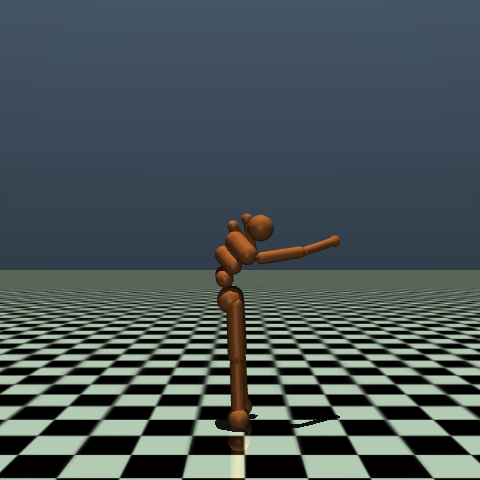

In [14]:


# 1. Crear entorno con renderizado en formato imagen
env = gym.make("Humanoid-v5", render_mode="rgb_array")
obs, info = env.reset()

# 2. Bucle de simulación
for step in range(300):  # Ajusta según necesites (300 ~ 5-6 segundos)
    action, _ = model.predict(obs, deterministic=True)#env.action_space.sample()  # ← Reemplaza por tu política/agente
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    if frame is not None:
        clear_output(wait=True)  # Limpia la celda sin parpadeo
        display(PILImage.fromarray(frame))

    if terminated or truncated:
        obs, info = env.reset()

    time.sleep(0.03)  # Controla la velocidad de reproducción

env.close()